<a href="https://colab.research.google.com/github/ayannaavalos/158/blob/main/158_Iris_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Part 2. Python Implementation of Iris Recogntion

Option 2:  implement the classification part from scratch, and the feature extraction can come from the existing MATLAB functions: focus is on classifiers, compare different classification methods (minimum 2).

The dataset used is the [CASIA-Iris-Thousand](https://https://www.kaggle.com/datasets/sondosaabed/casia-iris-thousand) (first 1000 instances)

###Summarization:

*  Preprocessing: Grayscale,Flattened Vectors, Z-Score
*  Feature Extraction: HOG
*  Feature Selction: Variance Threshold
*  Dim. Reduction: PCA
*  Classification (Implemented): K-Nearest Neighbor (KNN) and Support Vector Machine (SVM)

###Brief Discussion on Results
KNN had a performance of 0.74% accuracy while SVMs had a performance of 0.445%. This may be due to there being 50 classes (people) in the dataset but not many examples (images) for each class. The KNN is naturally multi-class and does not have to learn the data, it compares it directly. SVM on the otherhand, is binary and attempts to learn the boundaries between the classes but there are only a few examples for each. PCA works well with KNN as it preserves variance but not class separability (so it may make it more difficult for SVM classifier). Additionally, SVM may not be trained to its optimial performance (with plenty of classes, iterations were limited to 500).




### Imports and Loading Data

In [161]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.feature_selection import VarianceThreshold
from collections import Counter
from skimage.feature import hog
from sklearn.neighbors import KNeighborsClassifier
from skimage import exposure
import cv2
import numpy as np
from tabulate import tabulate
from sklearn.svm import SVC

In [124]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
#load the dataset
file_path = '/content/drive/MyDrive/archive/iris_thousands.csv'
df = pd.read_csv(file_path)

#fix column names to be all lowercase
df.columns = df.columns.str.lower()

#the dataset is very alrge with 20,000 images, we are implementing with the first 1,000 examples
df = df.head(1000).reset_index(drop=True)

# replace imagepath from kaggle to use the updated Drive path
df['imagepath'] = df['imagepath'].apply(lambda x: x.replace(
    '/kaggle/input/casia-iris-thousand/', '/content/drive/MyDrive/archive/'))

#display updated paths to double check
print(df['imagepath'].head())

0    /content/drive/MyDrive/archive/CASIA-Iris-Thou...
1    /content/drive/MyDrive/archive/CASIA-Iris-Thou...
2    /content/drive/MyDrive/archive/CASIA-Iris-Thou...
3    /content/drive/MyDrive/archive/CASIA-Iris-Thou...
4    /content/drive/MyDrive/archive/CASIA-Iris-Thou...
Name: imagepath, dtype: object


  0%|          | 53/20000 [22:48<143:05:05, 25.82s/it]


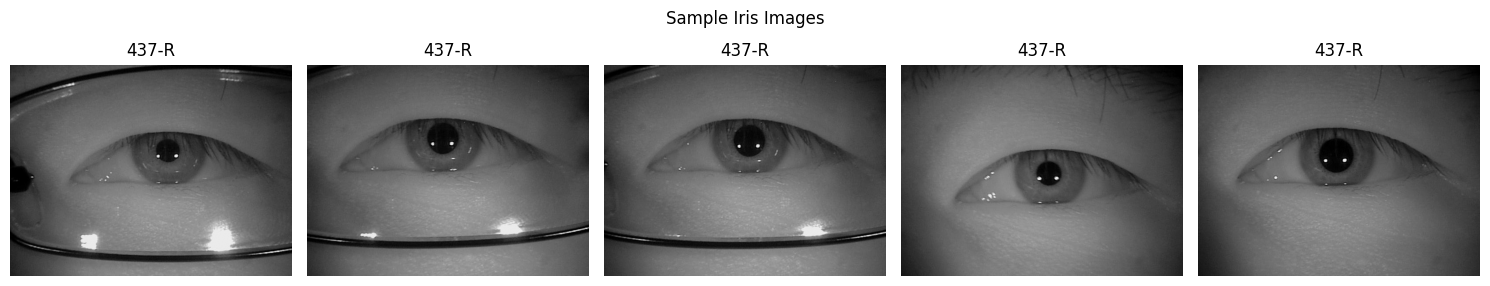

In [24]:
#to ensure the paths are functional, display the first 5 images
plt.figure(figsize=(15, 3))

for i in range(5):
    img_path = df['imagepath'].iloc[i]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  #grayscale
    if img is not None:
        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(df['label'].iloc[i])
        plt.axis('off')
    else:
        print(f"Could not load image at {img_path}")

plt.suptitle("Sample Iris Images")
plt.tight_layout()
plt.show()

### Data Cleaning and Split
*   Only first 1000 instances are used, the dataset is extremely large
*   Group all images by individuals (using IDs)
*   For each individual, split their data into training (80%) and testing (20%) sets.
*   Create one final training and testing set that combines all the individuals sets.





In [126]:
#extract person IDs and split into groups
df['person_id'] = df['label'].apply(lambda x: x.split('-')[0])

#person ID from label
df['person_id'] = df['label'].apply(lambda x: x.split('-')[0])

# group by person ID, and split each group into train/test
from sklearn.model_selection import train_test_split

train_rows = []
test_rows = []

for _, group in df.groupby('person_id'):
    if len(group) < 2:
        continue  # not enough samples to split
    train, test = train_test_split(group, test_size=0.2, random_state=42)
    train_rows.append(train)
    test_rows.append(test)

#combine all into two final sets
df_train = pd.concat(train_rows).reset_index(drop=True)
df_test = pd.concat(test_rows).reset_index(drop=True)

### Feature Extraction/Normalization
*   Apply HOG to all images as well as visualize a few examples
*   Normalize the features (in preparation for PCA)
*   Feature Selction: remove features with low variance (0.01)





In [128]:
def extract_hog(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros(1024)
    img = cv2.resize(img, (64, 64))
    features, _ = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True
    )
    return features

# apply to all images in train/test sets
X_train = np.array([extract_hog(p) for p in tqdm(df_train['imagepath'])])
X_test = np.array([extract_hog(p) for p in tqdm(df_test['imagepath'])])

#extracts true label for the X datasets
y_train = df_train['person_id'].values
y_test = df_test['person_id'].values



100%|██████████| 200/200 [00:03<00:00, 52.32it/s]


In [129]:
#if any image results in a zero vector (if the image failed to load), it is removed
valid_train = ~np.all(X_train == 0, axis=1)
valid_test = ~np.all(X_test == 0, axis=1)

X_train, y_train = X_train[valid_train], y_train[valid_train]
X_test, y_test = X_test[valid_test], y_test[valid_test]

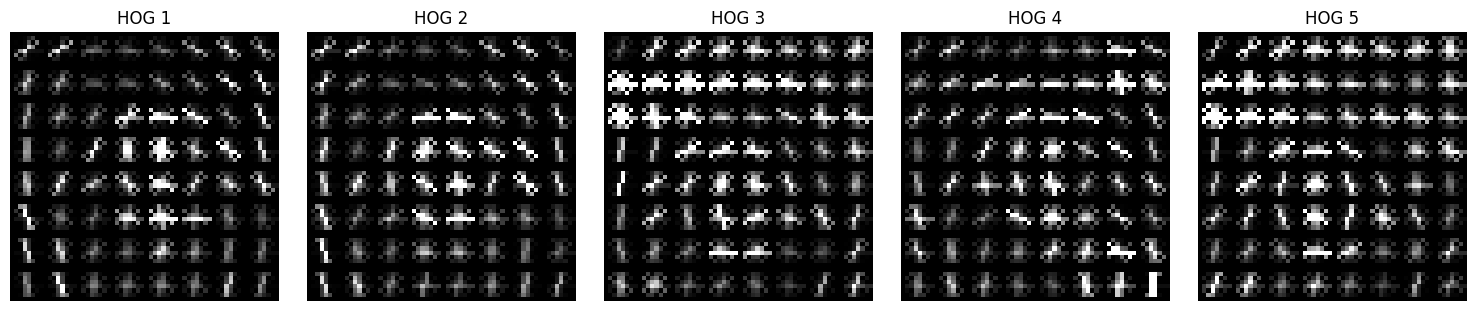

In [130]:
# 5 images from training set
sample_paths = df_train['imagepath'].head(5)

plt.figure(figsize=(15, 6))
for i, path in enumerate(sample_paths):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))

    # compute HOG + visualization
    features, hog_image = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True
    )
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    # show HOG image
    plt.subplot(2, 5, i + 6)
    plt.imshow(hog_image_rescaled, cmap='gray')
    plt.title(f"HOG {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [133]:
#z-score normalization to prepare for PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#FEATURE SELECTION: removes any features with very low variance
selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train_scaled)
X_test_var = selector.transform(X_test_scaled)

### Dimensionality Reduction: PCA
*  Reduces the feature space to 180 principal components in an attempt to try to keep 90% of variance (we keep 84%)
*   Visualize PCA





In [93]:
# apply PCA
pca = PCA(n_components=180)
X_train_pca = pca.fit_transform(X_train)
print(pca.explained_variance_ratio_.sum())

X_test_pca = pca.transform(X_test)

0.8474591565961086


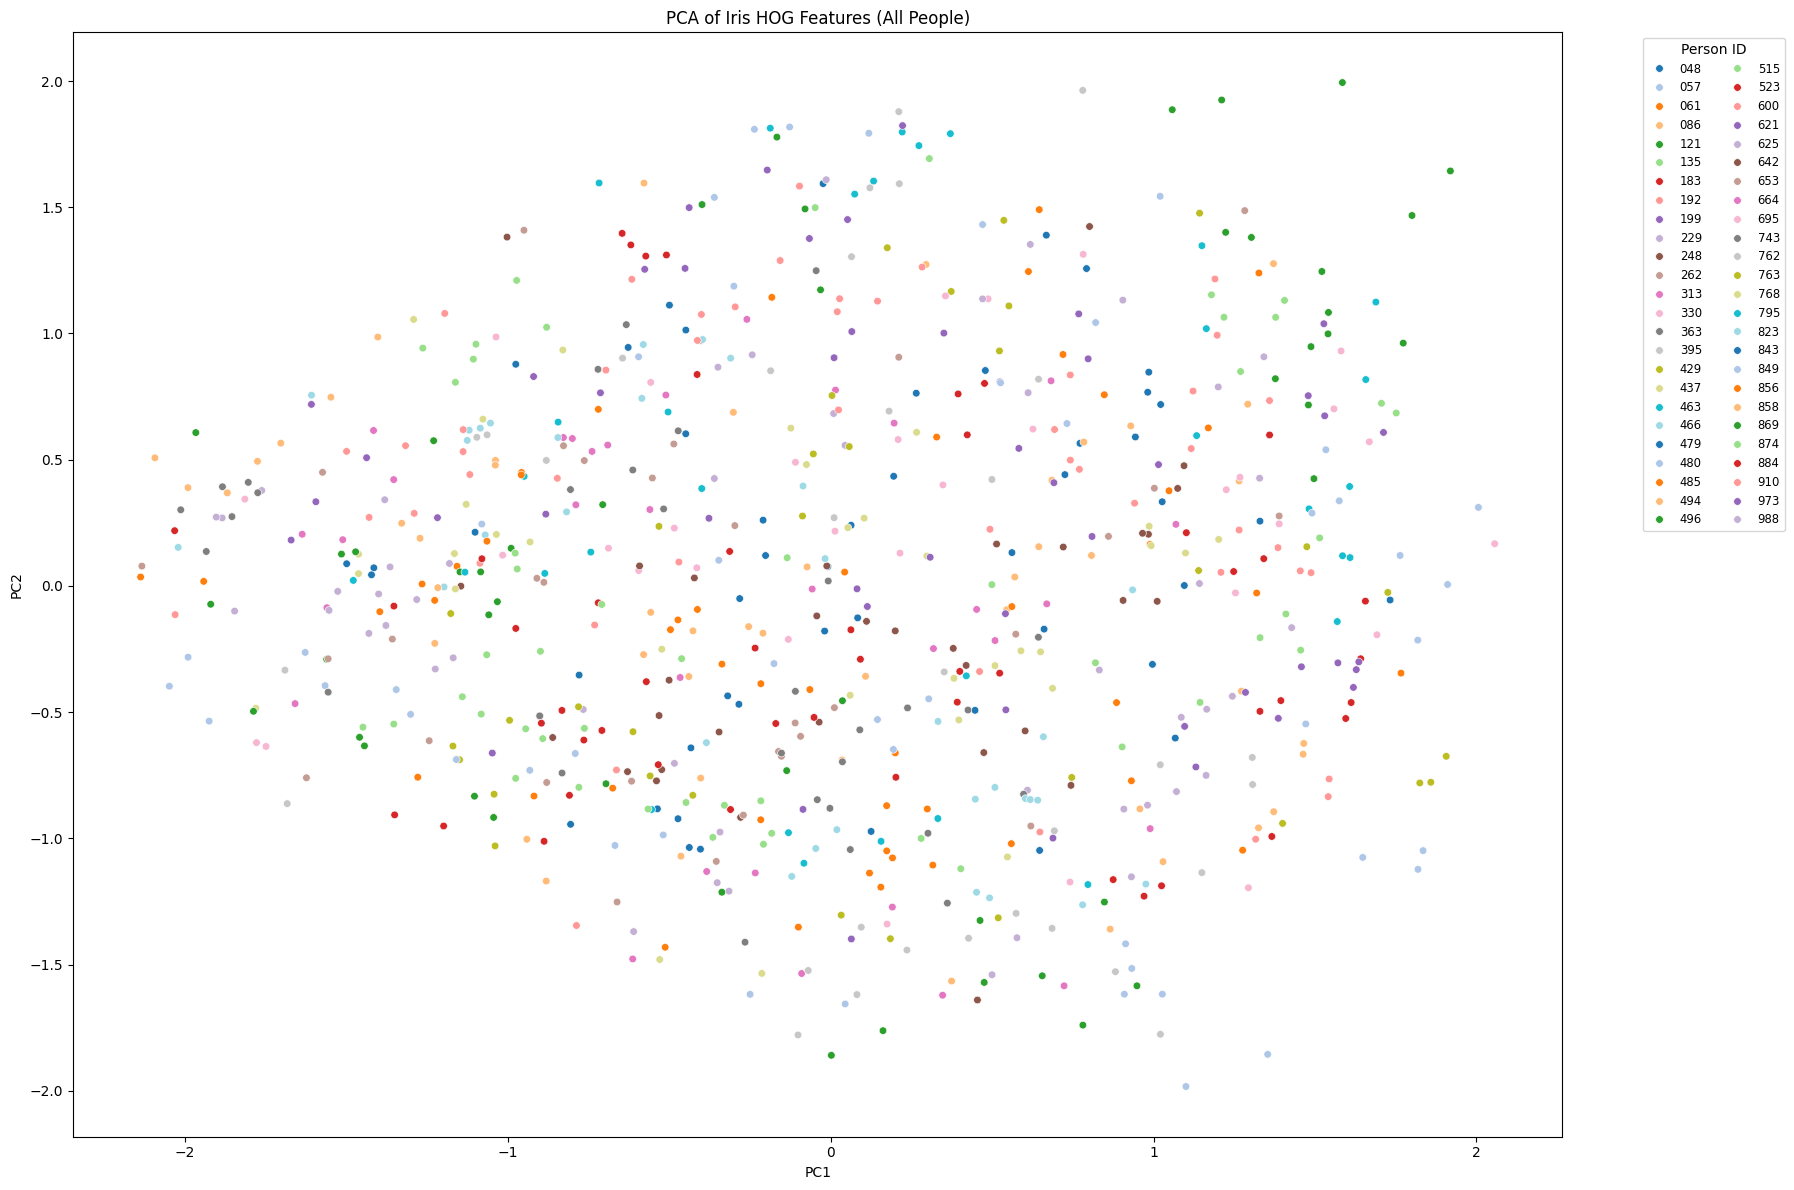

In [105]:
# convert to dataFrame for easier plotting
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['label'] = y_train

# plot
plt.figure(figsize=(18, 12))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='label',
    palette='tab20',  # or 'hsv', 'Spectral', 'Set3'
    s=30,
    legend='full'
)

plt.title("PCA of Iris HOG Features (All People)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small', title="Person ID")
plt.tight_layout()
plt.show()

### CLASSIFIER 1. KNN - Implementation



In [135]:
class CustomKNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X_test):
        predictions = []
        for x in X_test:
            # compute Euclidean distance to all training points
            distances = np.linalg.norm(self.X_train - x, axis=1)
            # find the indices of the k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            # get their labels
            k_labels = self.y_train[k_indices]
            # majority vote
            most_common = Counter(k_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return predictions


In [134]:
# initialize, k is set to three.
knn = CustomKNN(k=3)

# train
knn.fit(X_train_pca, y_train)

# predict
y_pred = knn.predict(X_test_pca)


### RESULTS: KNN
*   Accuracy of KNN model.
*   Classification Report: precision, recall, f1-score, support. (Confusion Matrix for all individuals has too much information to be displayed)
*   Report for each individual: Accuracy, TPR, FPR, AUC
*   Confusion Matricies for three individuals as examples.




In [122]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

#Confusion matrix for All People - looks TERRIBLE (too much info), do not use, print summary instead
#ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
#plt.title("Custom KNN Confusion Matrix")
#plt.tight_layout()
#plt.show()

print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.74
              precision    recall  f1-score   support

         048       0.50      0.25      0.33         4
         057       0.80      1.00      0.89         4
         061       0.00      0.00      0.00         4
         086       1.00      1.00      1.00         4
         121       0.75      0.75      0.75         4
         135       0.50      0.50      0.50         4
         183       1.00      0.75      0.86         4
         192       1.00      0.25      0.40         4
         199       0.75      0.75      0.75         4
         229       1.00      1.00      1.00         4
         248       1.00      0.75      0.86         4
         262       0.44      1.00      0.62         4
         313       0.67      0.50      0.57         4
         330       0.67      0.50      0.57         4
         363       1.00      0.75      0.86         4
         395       1.00      0.50      0.67         4
         429       0.75      0.75      0.75         4
         437

In [120]:
unique_labels = np.unique(y_test)

summary = []

for target in unique_labels:
    y_test_binary = (y_test == target).astype(int)
    y_pred_binary = (np.array(y_pred) == target).astype(int)

    # Skip targets with no presence
    if len(np.unique(y_test_binary)) < 2:
        continue

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_binary).ravel()

    # Metrics
    accuracy = accuracy_score(y_test_binary, y_pred_binary)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fpr_vals, tpr_vals, _ = roc_curve(y_test_binary, y_pred_binary)
    roc_auc = auc(fpr_vals, tpr_vals)

    summary.append({
        'Person': target,
        'Accuracy': round(accuracy, 2),
        'TPR (Recall)': round(tpr, 2),
        'FPR': round(fpr, 2),
        'AUC': round(roc_auc, 2)
    })

# Create DataFrame
summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display
print(tabulate(summary_df, headers='keys', tablefmt='github', showindex=False))

|   Person |   Accuracy |   TPR (Recall) |   FPR |   AUC |
|----------|------------|----------------|-------|-------|
|      229 |       1    |           1    |  0    |  1    |
|      086 |       1    |           1    |  0    |  1    |
|      762 |       1    |           1    |  0    |  1    |
|      695 |       1    |           1    |  0    |  1    |
|      849 |       1    |           1    |  0    |  1    |
|      795 |       1    |           1    |  0    |  1    |
|      494 |       1    |           1    |  0    |  1    |
|      479 |       1    |           1    |  0    |  1    |
|      437 |       0.99 |           1    |  0.01 |  1    |
|      057 |       0.99 |           1    |  0.01 |  1    |
|      363 |       0.99 |           0.75 |  0    |  0.88 |
|      600 |       0.99 |           0.5  |  0    |  0.75 |
|      183 |       0.99 |           0.75 |  0    |  0.88 |
|      121 |       0.99 |           0.75 |  0.01 |  0.87 |
|      199 |       0.99 |           0.75 |  0.01 |  0.87

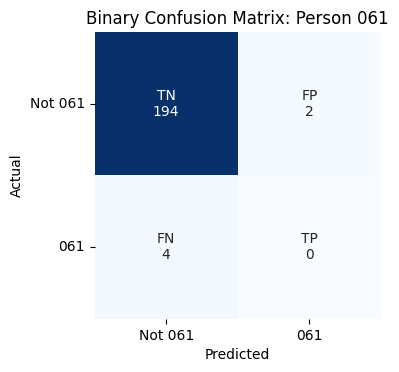

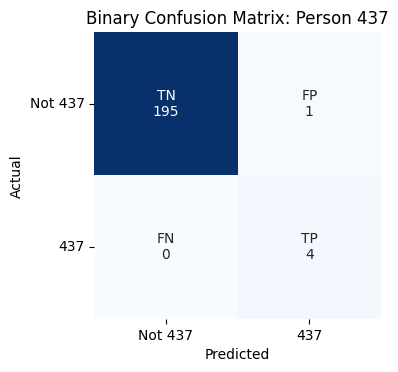

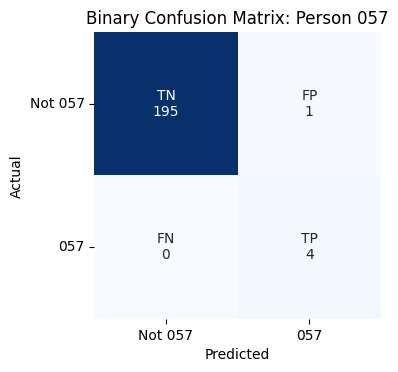

In [108]:
# select a few person IDs to evaluate individually
target_ids = ['061', '437', '057']

for target in target_ids:
    y_test_binary = (y_test == target).astype(int)
    y_pred_binary = (np.array(y_pred) == target).astype(int)

    # compute confusion matrix and unpack values
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    if cm.shape != (2, 2):  # skip if not binary (e.g., no positives)
        print(f"Skipping {target}: insufficient class presence in test set")
        continue

    tn, fp, fn, tp = cm.ravel()

    # build matrix with labels and values
    labels = np.array([["TN", "FP"], ["FN", "TP"]])
    values = np.array([[tn, fp], [fn, tp]])

    plt.figure(figsize=(4, 4))
    sns.heatmap(values, annot=labels + "\n" + values.astype(str), fmt="", cmap="Blues", cbar=False, square=True)

    plt.title(f"Binary Confusion Matrix: Person {target}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], [f"Not {target}", target])
    plt.yticks([0.5, 1.5], [f"Not {target}", target], rotation=0)
    plt.tight_layout()
    plt.show()

###CLASSIFIER 2. SVM - Implementation

In [147]:
class LinearSVM:
    #initialize model with parameters (could maybe improve here later)
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=500):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.classes = None
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        #unique classes for each person's ID
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes)

        # one SVM for each class because SVM is binary
        self.weights = np.zeros((n_classes, n_features))
        self.bias = np.zeros(n_classes)

        for idx, cls in enumerate(self.classes):
            print(f"Training class {idx + 1}/{n_classes} (Person ID: {cls})")
            y_binary = np.where(y == cls, 1, -1)
            w = np.zeros(n_features)
            b = 0

            #gradient descent
            for _ in range(self.n_iters):
                for i in range(n_samples):
                    condition = y_binary[i] * (np.dot(X[i], w) + b) >= 1
                    if condition:
                      #hinge loss condition
                        w -= self.lr * (2 * self.lambda_param * w)
                    else:
                       #apply hinge loss gradient update + regularization
                        w -= self.lr * (2 * self.lambda_param * w - np.dot(X[i], y_binary[i]))
                        b -= self.lr * y_binary[i]
            #save weights/bias for each class
            self.weights[idx, :] = w
            self.bias[idx] = b

    def predict(self, X):
        X = np.array(X)
        # score for each class: X · W^T + b
        scores = np.dot(X, self.weights.T) + self.bias
        #pick highest score for each sample and return it
        preds = np.argmax(scores, axis=1)
        return self.classes[preds]

In [148]:
#initialize, train, test
svm = LinearSVM(learning_rate=0.001, lambda_param=0.01, n_iters=500)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)

Training class 1/50 (Person ID: 048)
Training class 2/50 (Person ID: 057)
Training class 3/50 (Person ID: 061)
Training class 4/50 (Person ID: 086)
Training class 5/50 (Person ID: 121)
Training class 6/50 (Person ID: 135)
Training class 7/50 (Person ID: 183)
Training class 8/50 (Person ID: 192)
Training class 9/50 (Person ID: 199)
Training class 10/50 (Person ID: 229)
Training class 11/50 (Person ID: 248)
Training class 12/50 (Person ID: 262)
Training class 13/50 (Person ID: 313)
Training class 14/50 (Person ID: 330)
Training class 15/50 (Person ID: 363)
Training class 16/50 (Person ID: 395)
Training class 17/50 (Person ID: 429)
Training class 18/50 (Person ID: 437)
Training class 19/50 (Person ID: 463)
Training class 20/50 (Person ID: 466)
Training class 21/50 (Person ID: 479)
Training class 22/50 (Person ID: 480)
Training class 23/50 (Person ID: 485)
Training class 24/50 (Person ID: 494)
Training class 25/50 (Person ID: 496)
Training class 26/50 (Person ID: 515)
Training class 27/50 

###RESULTS: SVM
*   Accuracy of KNN model.
*   Classification Report: precision, recall, f1-score, support.
*   Report for each individual: Accuracy, TPR, FPR, AUC
*   Confusion Matricies for three individuals as examples.


In [152]:
#evalute
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division=0))

Accuracy: 0.445
              precision    recall  f1-score   support

         048       0.00      0.00      0.00         4
         057       0.38      0.75      0.50         4
         061       0.00      0.00      0.00         4
         086       1.00      0.50      0.67         4
         121       0.00      0.00      0.00         4
         135       0.00      0.00      0.00         4
         183       0.75      0.75      0.75         4
         192       0.00      0.00      0.00         4
         199       0.20      1.00      0.33         4
         229       0.80      1.00      0.89         4
         248       1.00      0.75      0.86         4
         262       0.31      1.00      0.47         4
         313       1.00      0.50      0.67         4
         330       0.50      0.25      0.33         4
         363       0.43      0.75      0.55         4
         395       0.00      0.00      0.00         4
         429       1.00      0.25      0.40         4
         43

In [153]:
unique_labels = np.unique(y_test)
summary = []

for target in unique_labels:
    y_test_binary = (y_test == target).astype(int)
    y_pred_binary = (np.array(y_pred_svm) == target).astype(int)

    if len(np.unique(y_test_binary)) < 2:
        continue  # skip if class isn't present in test set

    # confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_binary).ravel()

    #metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fpr_vals, tpr_vals, _ = roc_curve(y_test_binary, y_pred_binary)
    roc_auc = auc(fpr_vals, tpr_vals)

    summary.append({
        'Person': target,
        'Accuracy': round(accuracy, 2),
        'TPR (Recall)': round(tpr, 2),
        'FPR': round(fpr, 2),
        'AUC': round(roc_auc, 2)
    })

#display
summary_df = pd.DataFrame(summary).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

Person  Accuracy  TPR (Recall)  FPR  AUC
   248      1.00          0.75 0.00 0.88
   229      1.00          1.00 0.01 1.00
   823      1.00          1.00 0.00 1.00
   313      0.99          0.50 0.00 0.75
   183      0.99          0.75 0.01 0.87
   086      0.99          0.50 0.00 0.75
   523      0.99          1.00 0.01 0.99
   642      0.99          0.50 0.00 0.75
   479      0.99          0.50 0.00 0.75
   858      0.99          0.50 0.00 0.75
   988      0.99          0.50 0.00 0.75
   795      0.99          0.50 0.00 0.75
   330      0.98          0.25 0.01 0.62
   048      0.98          0.00 0.00 0.50
   437      0.98          0.75 0.01 0.87
   121      0.98          0.00 0.00 0.50
   135      0.98          0.00 0.00 0.50
   061      0.98          0.00 0.01 0.50
   910      0.98          0.25 0.00 0.62
   849      0.98          0.75 0.02 0.87
   884      0.98          0.50 0.01 0.75
   874      0.98          1.00 0.03 0.99
   843      0.98          0.50 0.01 0.75
   363      0.98

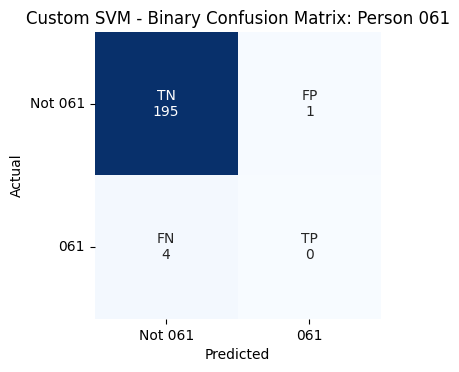

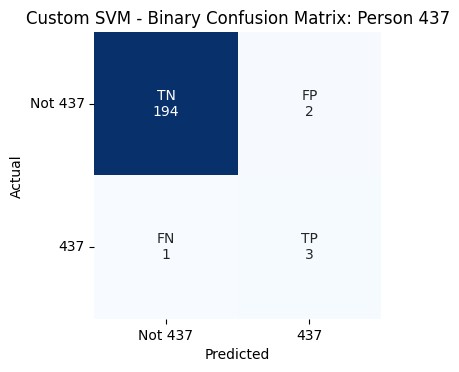

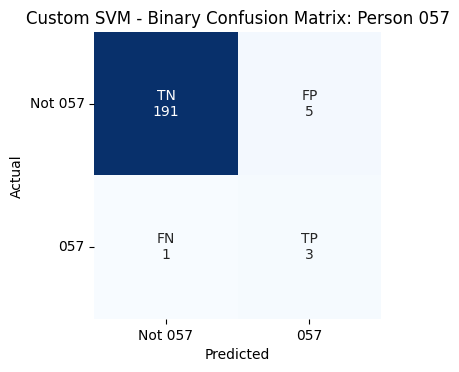

In [164]:
# same people from before
target_ids = ['061', '437', '057']

for target in target_ids:
    y_test_binary = (y_test == target).astype(int)
    y_pred_binary = (np.array(y_pred_svm) == target).astype(int)

    # compute confusion matrix
    cm = confusion_matrix(y_test_binary, y_pred_binary)

    if cm.shape != (2, 2):  # Skip if target class is missing
        print(f"Skipping {target}: insufficient class presence in test set")
        continue

    tn, fp, fn, tp = cm.ravel()

    # create labeled matrix
    labels = np.array([["TN", "FP"], ["FN", "TP"]])
    values = np.array([[tn, fp], [fn, tp]])

    # plot
    plt.figure(figsize=(4, 4))
    sns.heatmap(
        values,
        annot=labels + "\n" + values.astype(str),
        fmt="",
        cmap="Blues",
        cbar=False,
        square=True
    )

    plt.title(f"Custom SVM - Binary Confusion Matrix: Person {target}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], [f"Not {target}", target])
    plt.yticks([0.5, 1.5], [f"Not {target}", target], rotation=0)
    plt.tight_layout()
    plt.show()

### Baseline Comparision Metrics: Results for KNN and SVM using existing libraries


In [163]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_pca, y_train)
y_pred_knn = knn_model.predict(X_test_pca)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

svm_model = SVC(kernel='linear', C=1.0, probability=True)
svm_model.fit(X_train_pca, y_train)
y_pred_sklearn = svm_model.predict(X_test_pca)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_sklearn))


KNN Accuracy: 0.67
SVM Accuracy: 0.8
